In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers
import speed_plotting_helpers

In [3]:
activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


# Using bootstrap p-val threshold
Subtract basesline activities. Use class called from bootstrap comparison to t = 0. 

In [4]:
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


In [5]:
import pandas as pd

def summarize_adseq_activity(df, use_norm=True):
    y = "activity_norm" if use_norm else "activity"

    results = []

    for ad, grp in df.sort_values("time").groupby("ADseq"):
        grp = grp.sort_values("time")

        # --- 1. first time labeled as activator ---
        activator_grp = grp[grp["class"] == "activator"]

        if len(activator_grp) > 0:
            first_active_time = activator_grp.iloc[0]["time"]
        else:
            first_active_time = None  # never active

        # --- 2. max activity (across all timepoints) ---
        max_idx = grp[y].idxmax()
        max_row = grp.loc[max_idx]

        results.append({
            "ADseq": ad,
            "first_pass_time": first_active_time,
            "max_activity": max_row[y],
        })

    return pd.DataFrame(results)

In [6]:
first_time_vs_active = summarize_adseq_activity(activities)
first_time_vs_active

,ADseq,first_pass_time,max_activity
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.210488
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,5,2.359397
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,5,2.032776
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,5,2.527994
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,30,0.890615
...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,10,1.469611
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,30,1.090644
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5,4.379672
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,5,2.794890


/tmp/ipykernel_2603365/2783771276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


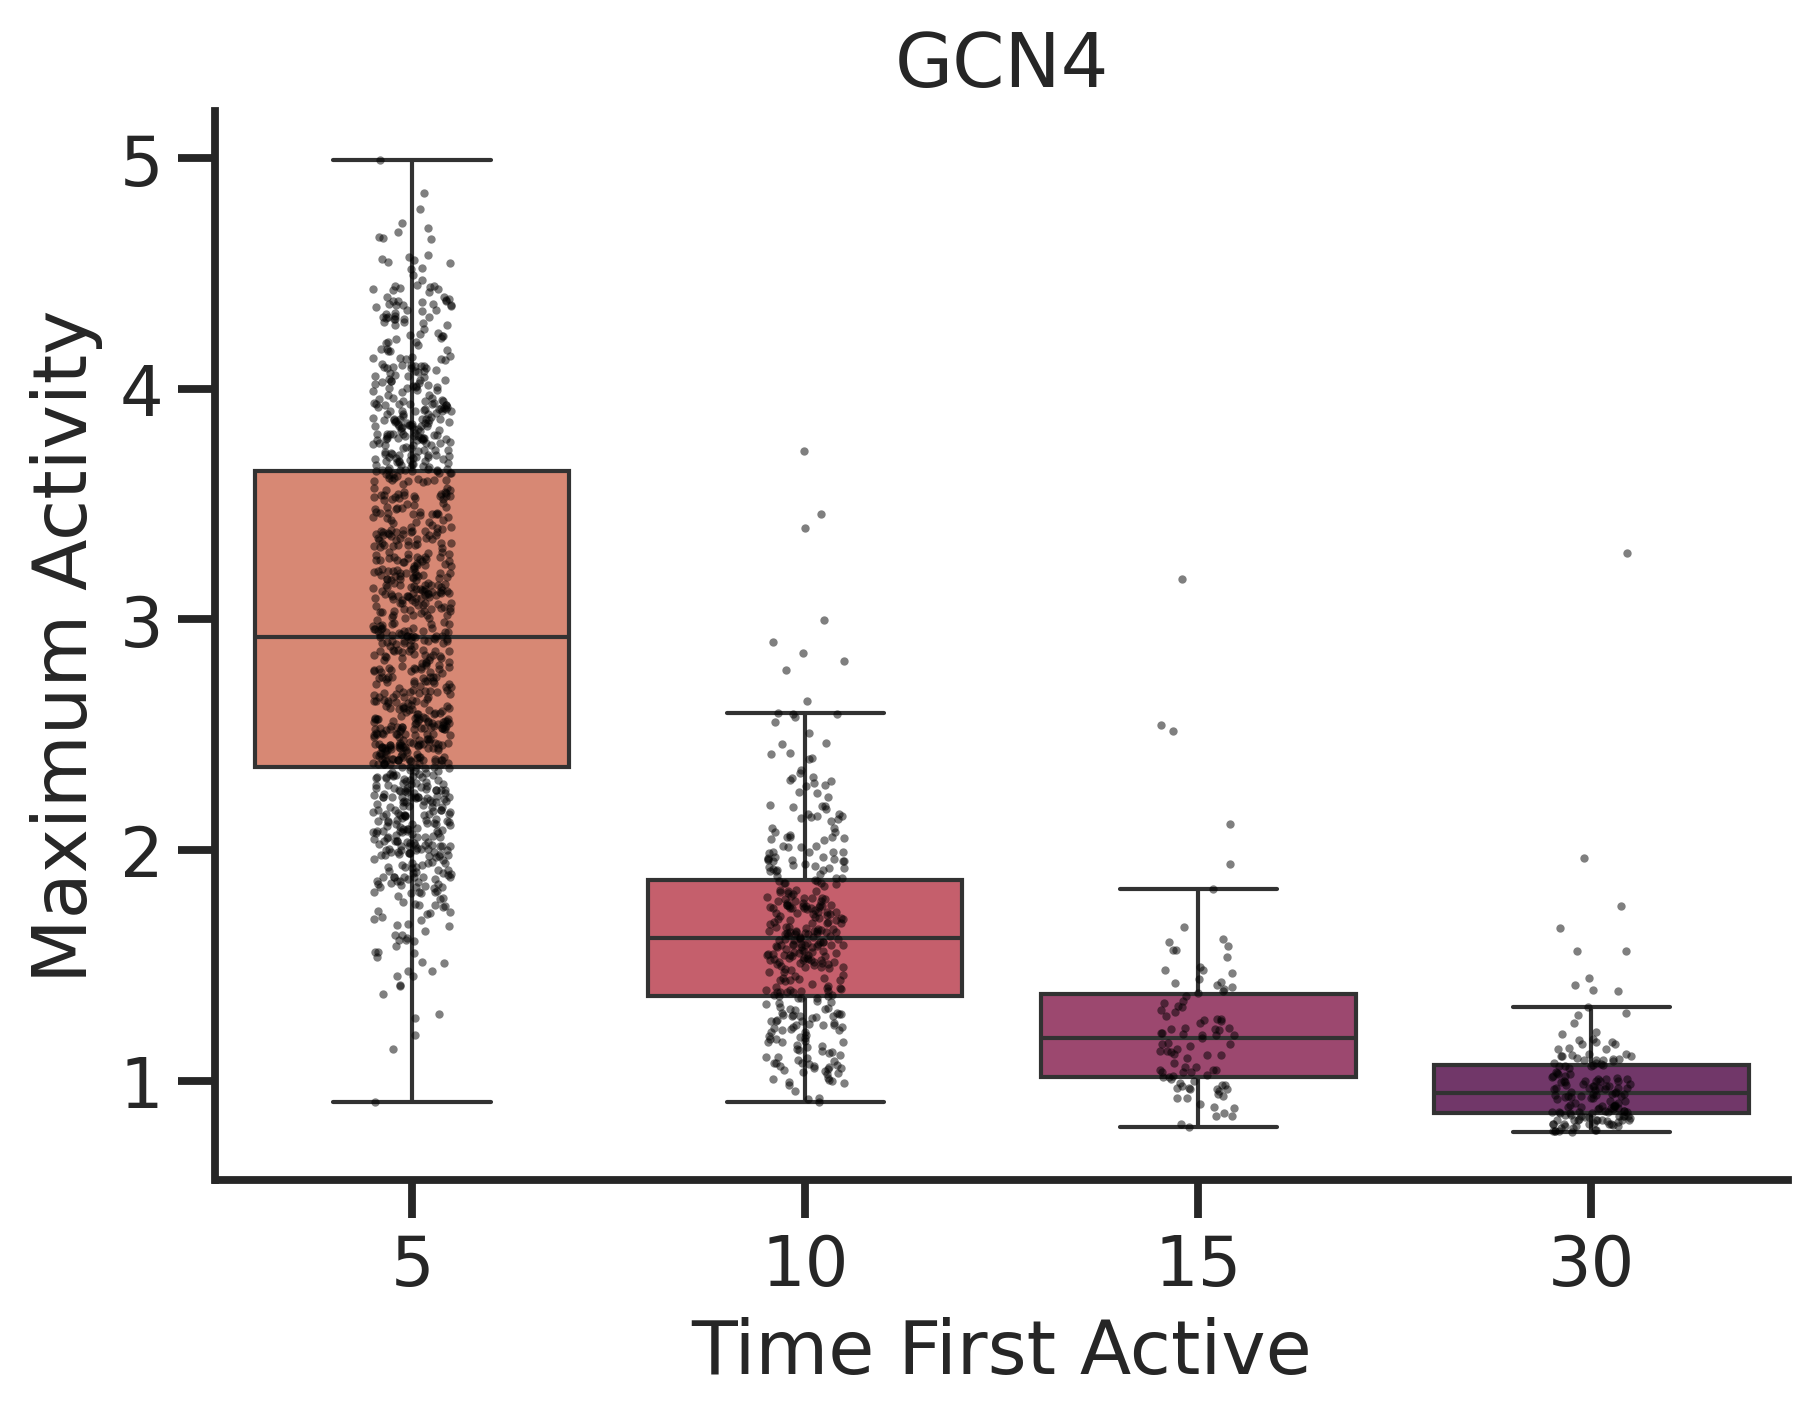

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk")

fig, ax = plt.subplots(dpi=300)

# --- boxplot FIRST (background) ---
sns.boxplot(
    data=first_time_vs_active,
    x="first_pass_time",
    y="max_activity",
    ax=ax,
    fliersize=0,
    linewidth=1,
    palette = 'flare'
)

# --- stripplot ON TOP ---
sns.stripplot(
    data=first_time_vs_active,
    x="first_pass_time",
    y="max_activity",
    ax=ax,
    alpha=0.5,
    size=2,
    color = 'black'
)

plt.ylabel("Maximum Activity")
plt.xlabel("Time First Active")

sns.despine()
plt.tight_layout()
plt.title("GCN4")
plt.show()


In [8]:
first_time_vs_active.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/first_passage_pval_class.csv")